1. Introduction
2. Dataset Overview
3. Data Cleaning
4. Event Distribution
5. User Behavior Funnel
6. Conversion Metrics
7. Traffic Source Analysis
8. Device Usage Analysis
9. Business Insights

In [1]:
import pandas as pd

df = pd.read_csv("../data/ga4_event_2021.csv")

df.head()

,event_date,event_timestamp,event_name,event_params.key,event_params.value.string_value,event_params.value.int_value,event_params.value.float_value,event_params.value.double_value,event_previous_timestamp,event_value_in_usd,...,items.coupon,items.affiliation,items.location_id,items.item_list_id,items.item_list_name,items.item_list_index,items.promotion_id,items.promotion_name,items.creative_name,items.creative_slot
0,20210121.0,1.611210e+15,page_view,engagement_time_msec,NaN,13.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,debug_mode,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,ga_session_number,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,page_referrer,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,page_location,https://www.googlemerchandisestore.com/,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
df_clean = df[df["event_name"].notna()].copy()

df_clean.head()

df_clean["event_timestamp"] = pd.to_datetime(df_clean["event_timestamp"], unit="us")
df_clean["date"] = df_clean["event_timestamp"].dt.date
df_clean["event_name"].value_counts()

event_name
page_view           13
scroll              11
session_start        8
view_promotion       7
user_engagement      7
first_visit          5
view_item            3
select_promotion     1
Name: count, dtype: int64

In [3]:
funnel = df_clean["event_name"].value_counts()

funnel


event_name
page_view           13
scroll              11
session_start        8
view_promotion       7
user_engagement      7
first_visit          5
view_item            3
select_promotion     1
Name: count, dtype: int64

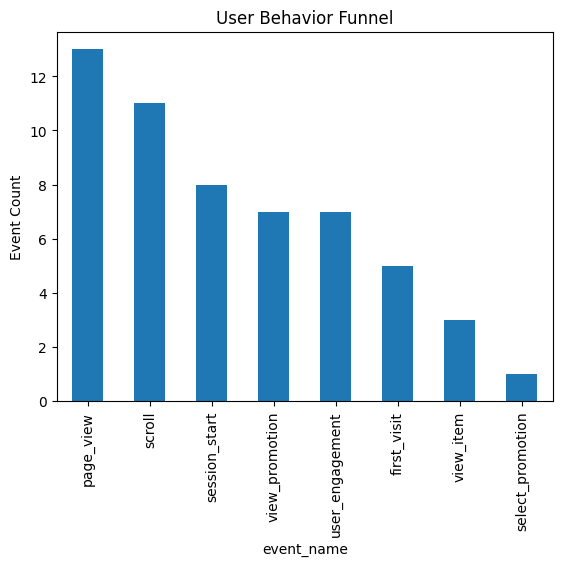

In [4]:
import matplotlib.pyplot as plt

funnel.plot(kind="bar")
plt.title("User Behavior Funnel")
plt.ylabel("Event Count")
plt.show()

In [5]:
users = df_clean["user_pseudo_id"].nunique()

print("Total Users:", users)

Total Users: 38


In [6]:
purchases = df_clean[df_clean["event_name"] == "purchase"]
conversion_rate = len(purchases) / users
print("Conversion Rate:", conversion_rate)

Conversion Rate: 0.0


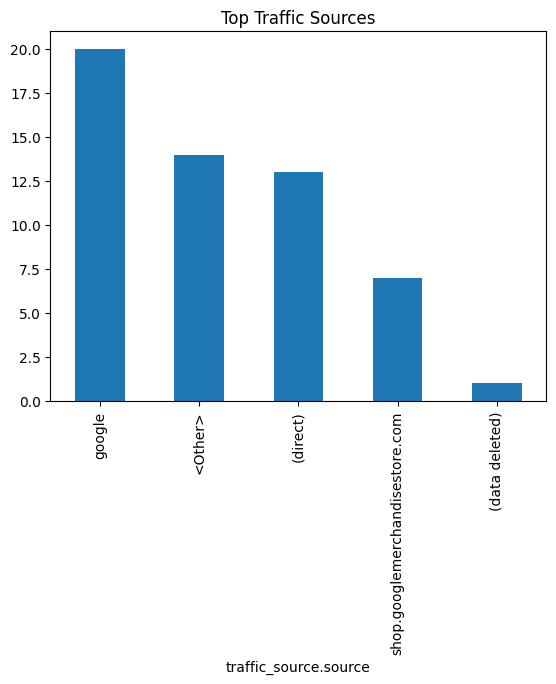

In [7]:
import matplotlib.pyplot as plt

df_clean["traffic_source.source"].value_counts().head(10)
df_clean["traffic_source.source"].value_counts().head(10).plot(kind="bar")
plt.title("Top Traffic Sources")
plt.show()

In [8]:
df_clean["device.category"].value_counts()

device.category
desktop    37
mobile     18
Name: count, dtype: int64

In [9]:
df_clean["ecommerce.purchase_revenue"].sum()
df_clean.groupby("items.item_name")["items.price"].sum().sort_values(ascending=False)
df_clean.to_csv("clean_product_events.csv", index=False)

In [10]:
page_views = 13
product_views = 3

product_view_rate = product_views / page_views

print("Product View Rate:", product_view_rate)

Product View Rate: 0.23076923076923078


In [12]:
promotion_views = 7
promotion_clicks = 1

promotion_ctr = promotion_clicks / promotion_views

print("Promotion CTR:", promotion_ctr)

Promotion CTR: 0.14285714285714285


<Axes: xlabel='event_name'>

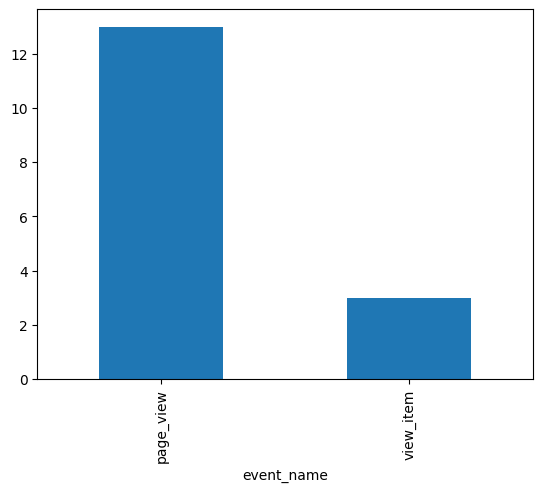

In [13]:
import matplotlib.pyplot as plt

funnel_events = ['page_view','view_item','add_to_cart','purchase']
funnel_df = df_clean[df_clean['event_name'].isin(funnel_events)]
funnel_counts = funnel_df['event_name'].value_counts()
funnel_counts.plot(kind='bar')

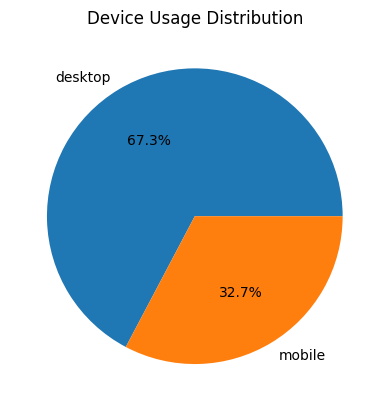

In [14]:
import matplotlib.pyplot as plt

device_counts = df_clean['device.category'].value_counts()

device_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Device Usage Distribution")
plt.ylabel("")
plt.show()